In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_pickle('../Data/df_clean.pkl')
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,is_promotion,competitor_pricing,seasonality,is_epidemic,demand,year,month,day,day_of_week
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday


## III. Detección y Tratamiento de Outliers

Identificación, caracterización y eliminación de outliers en `demand`, con foco en el producto P0009. Se parte del mismo dataset `df_clean.pkl`.

### 3.1 Diagnóstico Inicial — Distribución Global de la Demanda

Boxplot e histograma para evaluar la forma de la distribución. Cálculo del rango intercuartílico (IQR) y tabla de percentiles clave.

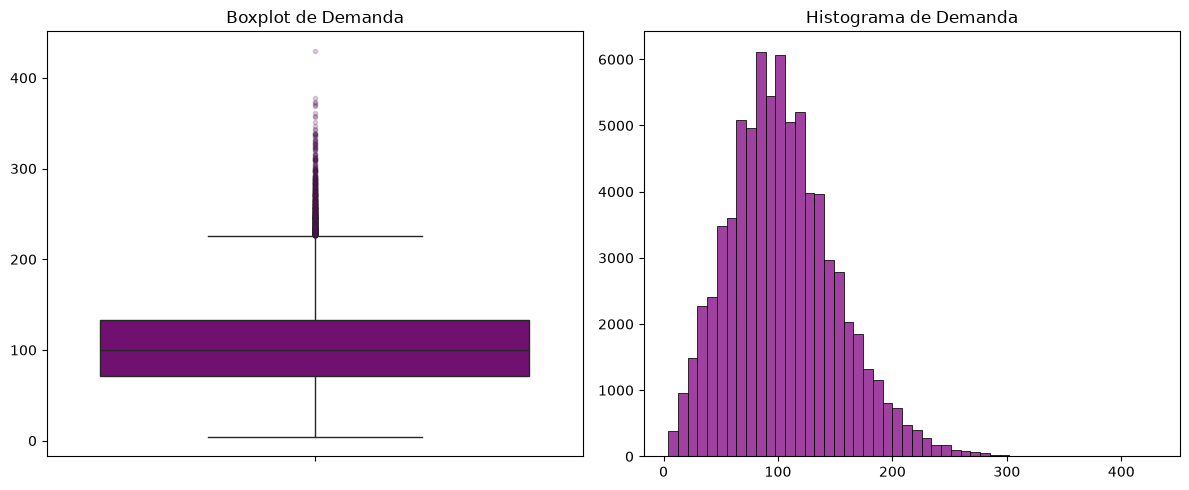

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, y='demand', ax=axes[0], color='purple',
    flierprops=dict(marker='o', markerfacecolor='purple', alpha=0.2, markersize=3))
sns.histplot(data=df, x='demand', bins=50, ax=axes[1], color='purple')
axes[0].set_title('Boxplot de Demanda')
axes[1].set_title('Histograma de Demanda')

axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')


plt.tight_layout()

In [4]:
q1, q3 = df['demand'].quantile(0.25), df['demand'].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f"Q1: {q1:.2f}  Q3: {q3:.2f}  IQR: {iqr:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}  Limite superior: {limite_superior:.2f}")
print(f"Valores bajo limite inferior: {(df['demand'] < limite_inferior).sum()}")
print(f"Valores sobre limite superior: {(df['demand'] > limite_superior).sum()}")

percentiles = [1, 5, 10, 20, 25, 50, 75, 80, 90, 95, 97.5, 99, 99.9, 99.99, 100]
display(pd.DataFrame([(p, df['demand'].quantile(p / 100)) for p in percentiles],
                     columns=["Percentil", "Valor"]).round(2))

Q1: 71.00  Q3: 133.00  IQR: 62.00
Limite inferior: -22.00  Limite superior: 226.00
Valores bajo limite inferior: 0
Valores sobre limite superior: 986


,Percentil,Valor
0,1.00,17.0
1,5.00,34.0
2,10.00,47.0
3,20.00,65.0
4,25.00,71.0
5,50.00,100.0
6,75.00,133.0
7,80.00,141.0
8,90.00,166.0
9,95.00,188.0


### 3.2 Identificación de Outliers

Detección mediante tres enfoques: regla IQR (1.5×IQR), límites de ±3 desviaciones estándar y puntuación Z-score (|z| > 3).

In [5]:
outliers = df[(df['demand'] < limite_inferior) | (df['demand'] > limite_superior)]['demand'].sort_values()
print(f"Cantidad total de outliers (IQR): {outliers.shape[0]}")
display(outliers)

Cantidad total de outliers (IQR): 986


2672     227
353      227
56353    227
3720     227
55852    227
        ... 
60261    370
53415    372
21885    373
21915    378
54387    430
Name: demand, Length: 986, dtype: int64

In [6]:
mu, std_ = df['demand'].mean(), df['demand'].std()
lim_inf_std, lim_sup_std = mu - 3*std_, mu + 3*std_
out_std = df['demand'][(df['demand'] < lim_inf_std) | (df['demand'] > lim_sup_std)]

print(f"Media: {mu:.2f}  Desviacion estandar: {std_:.2f}")
print(f"Limite inferior (+/-3sigma): {lim_inf_std:.2f}  Limite superior: {lim_sup_std:.2f}")
print(f"Outliers (+/-3sigma): {len(out_std)}")

z = (df['demand'] - mu) / std_
out_z = pd.DataFrame({'valor': df['demand'][z.abs() > 3].values,
                      'zscore': z[z.abs() > 3].round(3).values}).sort_values('zscore', ascending=False)
print(f"\nOutliers (|z| > 3): {len(out_z)}")
display(out_z)

Media: 104.32  Desviacion estandar: 46.96
Limite inferior (+/-3sigma): -36.58  Limite superior: 245.21
Outliers (+/-3sigma): 517

Outliers (|z| > 3): 517


,valor,zscore
351,430,6.935
146,378,5.827
145,373,5.721
330,372,5.700
468,370,5.657
...,...,...
385,246,3.017
105,246,3.017
441,246,3.017
126,246,3.017


### 3.3 Análisis Focalizado — Producto P0009

Filtrado del producto P0009, marcado y eliminación de outliers aplicando los límites IQR previamente calculados.

Outlier
False    3729
True       71
Name: count, dtype: int64

Registros originales: 3800  Sin outliers: 3729  Eliminados: 71


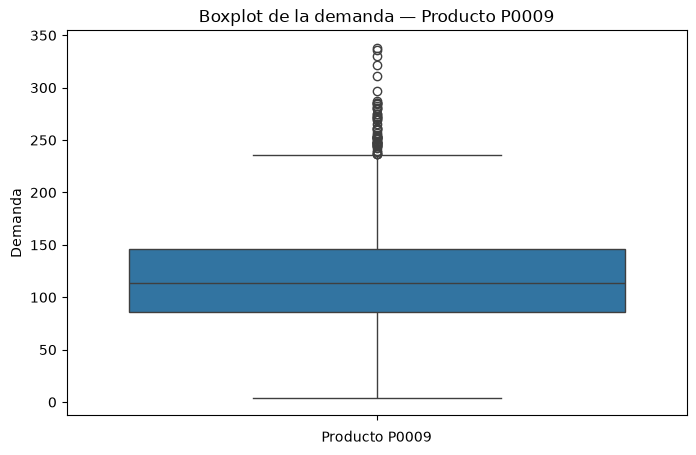

In [7]:
df_producto_9 = df[df["product_id"] == "P0009"].copy()
df_producto_9["Outlier"] = (
    (df_producto_9["demand"] < limite_inferior) |
    (df_producto_9["demand"] > limite_superior)
)
df_producto_9_sin_outliers = df_producto_9[~df_producto_9["Outlier"]].copy()

print(df_producto_9["Outlier"].value_counts())
print(f"\nRegistros originales: {len(df_producto_9)}  "
      f"Sin outliers: {len(df_producto_9_sin_outliers)}  "
      f"Eliminados: {len(df_producto_9) - len(df_producto_9_sin_outliers)}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_producto_9, y="demand", ax=ax)
ax.set(title="Boxplot de la demanda — Producto P0009", ylabel="Demanda", xlabel="Producto P0009")
plt.show()

### 3.4 Dataset Limpio — Estadísticos y Visualización

Estadísticos descriptivos, moda y mediana del dataset depurado. Panel de cuatro gráficos y matriz de correlación.

In [8]:
display(df_producto_9_sin_outliers["demand"].describe().to_frame())
print(f"Moda: {df_producto_9_sin_outliers['demand'].mode()[0]:.2f}   "
      f"Mediana: {df_producto_9_sin_outliers['demand'].median():.2f}")

,demand
count,3729.000000
mean,115.825691
std,42.039811
min,4.000000
25%,85.000000
50%,113.000000
75%,144.000000
max,226.000000


Moda: 101.00   Mediana: 113.00


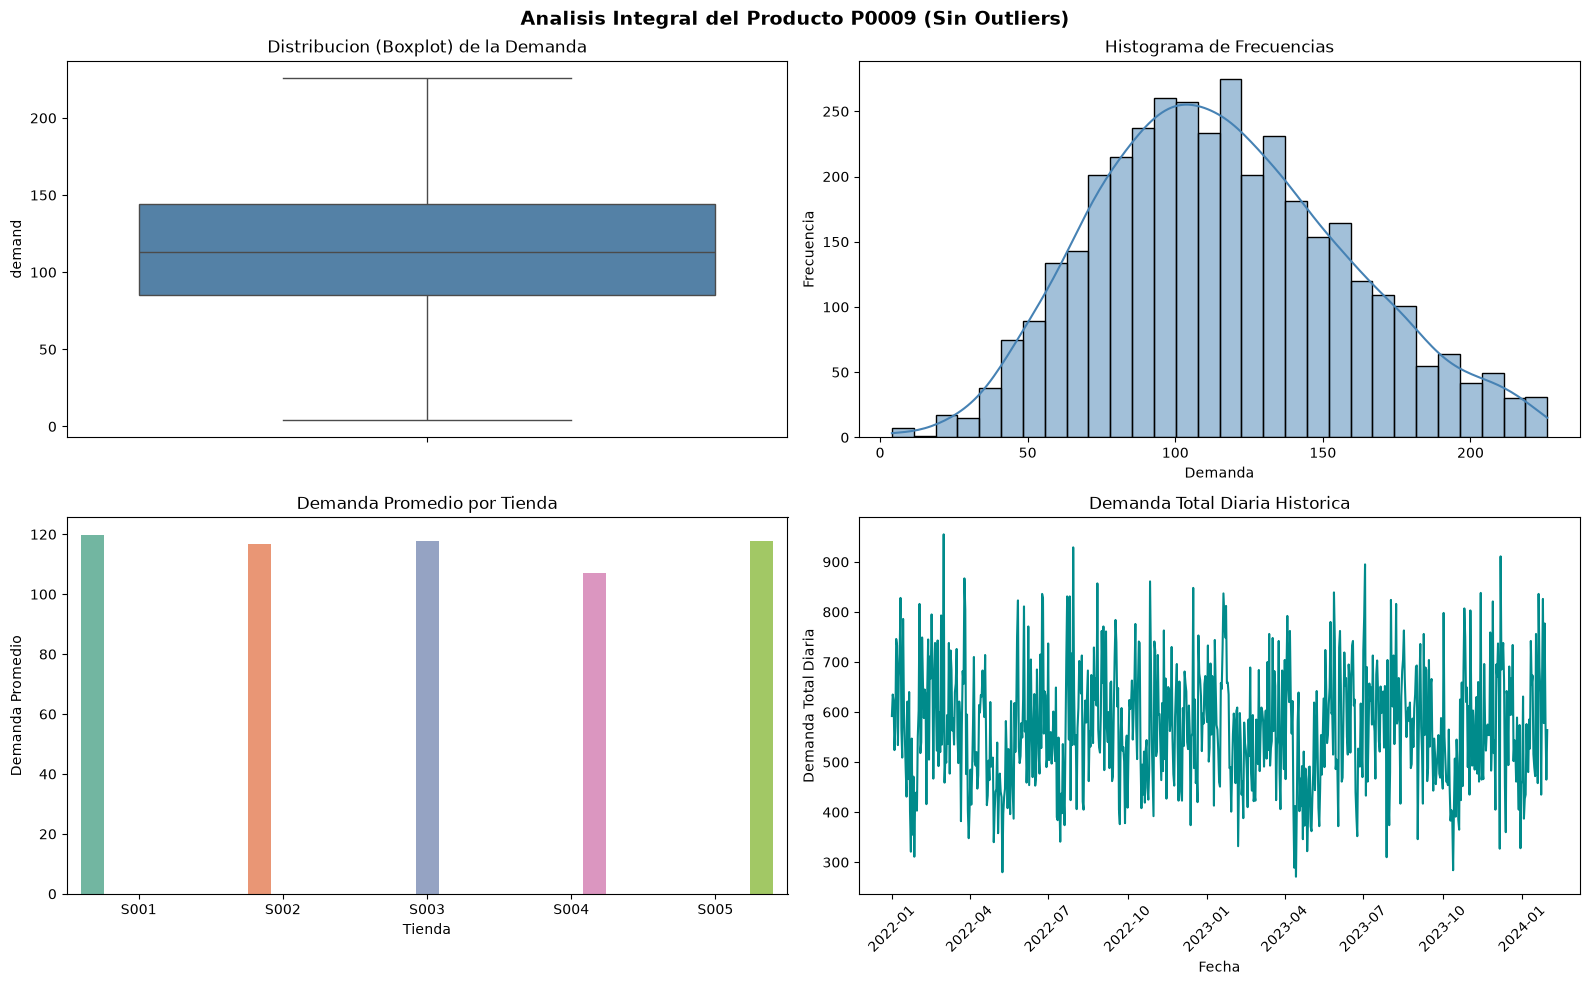

In [9]:
df_producto_9_sin_outliers["date"] = pd.to_datetime(df_producto_9_sin_outliers["date"])
df_p9    = df_producto_9_sin_outliers
df_store = df_p9.groupby("store_id")["demand"].mean().reset_index()
df_date  = df_p9.groupby("date")["demand"].sum().reset_index()

fig, ax = plt.subplots(2, 2, figsize=(16, 10))
ax = ax.flatten()

sns.boxplot(data=df_p9, y="demand", ax=ax[0], color="steelblue").set(
    title="Distribucion (Boxplot) de la Demanda", xlabel="")
sns.histplot(data=df_p9, x="demand", bins=30, kde=True, ax=ax[1], color="steelblue").set(
    title="Histograma de Frecuencias", xlabel="Demanda", ylabel="Frecuencia")
sns.barplot(data=df_store, x="store_id", y="demand", hue="store_id",
            palette="Set2", legend=False, ax=ax[2]).set(
    title="Demanda Promedio por Tienda", xlabel="Tienda", ylabel="Demanda Promedio")
sns.lineplot(data=df_date, x="date", y="demand", ax=ax[3], color="darkcyan").set(
    title="Demanda Total Diaria Historica", xlabel="Fecha", ylabel="Demanda Total Diaria")
ax[3].tick_params(axis="x", rotation=45)

plt.suptitle("Analisis Integral del Producto P0009 (Sin Outliers)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

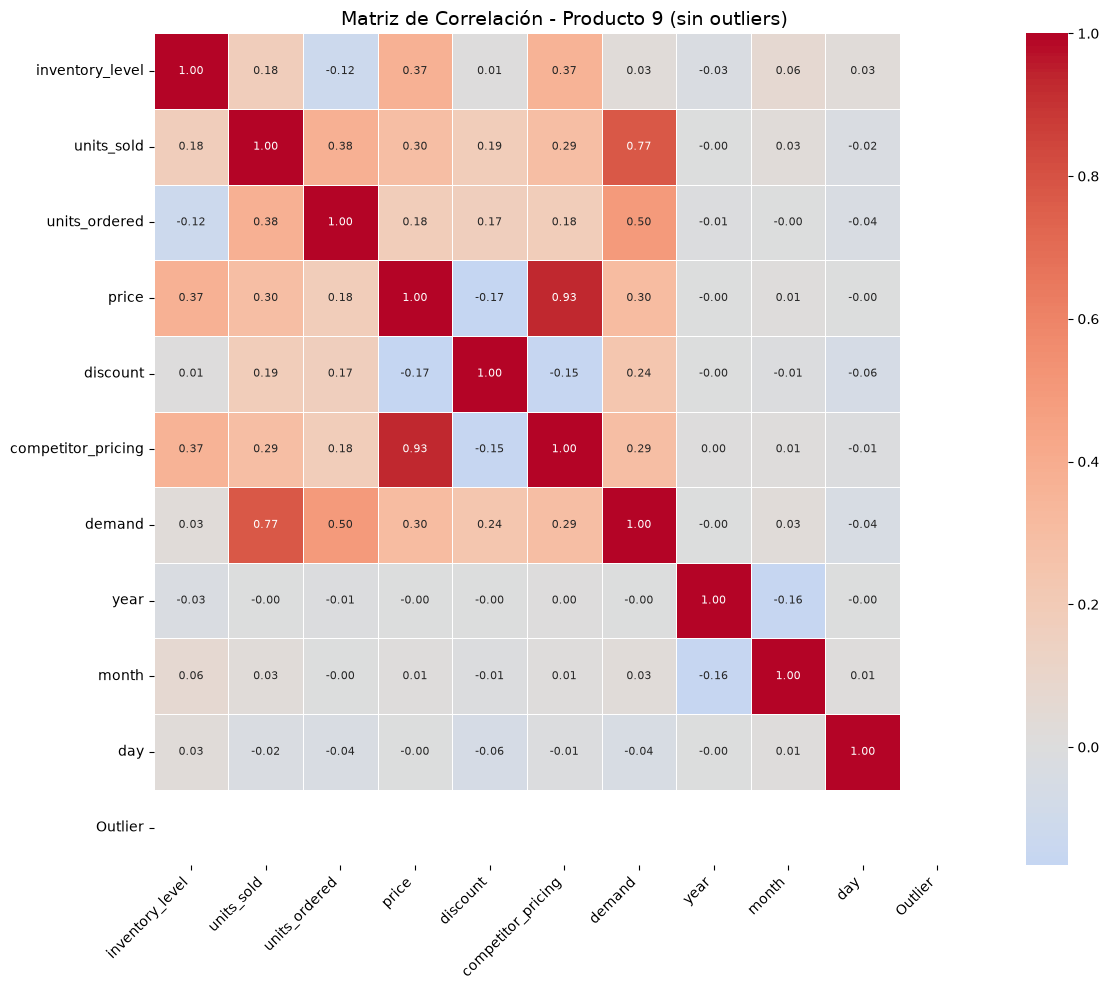

In [10]:
corr = df_producto_9_sin_outliers.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Matriz de Correlación - Producto 9 (sin outliers)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# Guardar
df_producto_9_sin_outliers.drop(columns = 'Outlier', inplace=True)
df_producto_9_sin_outliers.to_pickle("../Data/df_ready.pkl")